In [ ]:
import os
import shutil

pasta_origem = "/content"
pasta_destino = "/content/dataset_original"

classes = ["verde", "vermelho"]
for classe in classes:
    os.makedirs(f"{pasta_destino}/{classe}", exist_ok=True)

extensoes = (".jpg", ".jpeg", ".png")

arquivos = [f for f in os.listdir(pasta_origem) if f.lower().endswith(extensoes)]

for nome_img in arquivos:
    nome_lower = nome_img.lower()
    caminho_origem = os.path.join(pasta_origem, nome_img)

    if "verde" in nome_lower:
        destino = f"{pasta_destino}/verde/{nome_img}"

    elif "vermelho" in nome_lower:
        destino = f"{pasta_destino}/vermelho/{nome_img}"

    else:
        print(f"⚠️ Arquivo ignorado: {nome_img}")
        continue

    shutil.copy(caminho_origem, destino)

print("Organização corrigida ✅")

Organização corrigida ✅



📊 Verde - Resolução
Original: (2992, 2992, 3)
50%: (1496, 1496, 3)
20%: (598, 598, 3)


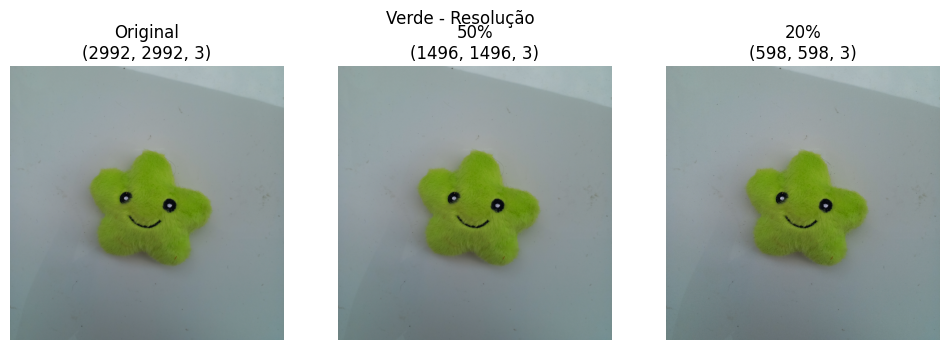


📊 Vermelho - Resolução
Original: (2992, 2992, 3)
50%: (1496, 1496, 3)
20%: (598, 598, 3)


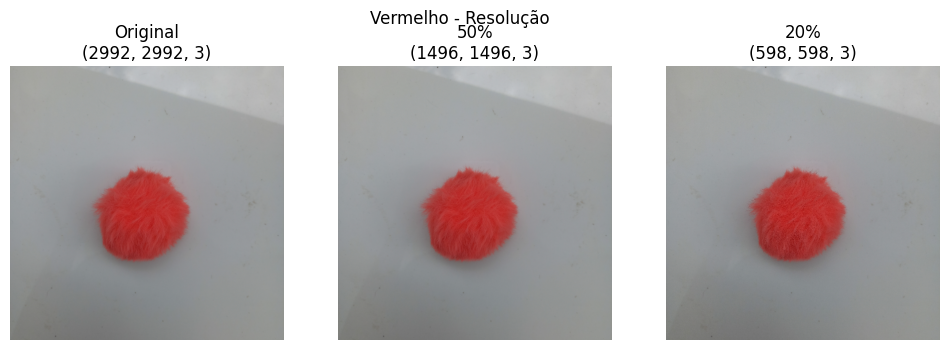

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Escolha manual de 1 imagem por classe
img_verde = cv2.imread("/content/dataset_original/verde/verde1.jpg")
img_vermelho = cv2.imread("/content/dataset_original/vermelho/vermelho1.jpg")

# Converter para RGB (para exibir corretamente)
img_verde = cv2.cvtColor(img_verde, cv2.COLOR_BGR2RGB)
img_vermelho = cv2.cvtColor(img_vermelho, cv2.COLOR_BGR2RGB)

def mostrar_resolucao(img, titulo):
    img_50 = cv2.resize(img, None, fx=0.5, fy=0.5)
    img_20 = cv2.resize(img, None, fx=0.2, fy=0.2)

    # 🔍 PRINT PARA PROVAR A MUDANÇA
    print(f"\n📊 {titulo}")
    print("Original:", img.shape)
    print("50%:", img_50.shape)
    print("20%:", img_20.shape)

    fig, ax = plt.subplots(1, 3, figsize=(12,4))

    ax[0].imshow(img)
    ax[0].set_title(f"Original\n{img.shape}")

    ax[1].imshow(img_50)
    ax[1].set_title(f"50%\n{img_50.shape}")

    ax[2].imshow(img_20)
    ax[2].set_title(f"20%\n{img_20.shape}")

    for a in ax:
        a.axis("off")

    plt.suptitle(titulo)
    plt.show()

mostrar_resolucao(img_verde, "Verde - Resolução")
mostrar_resolucao(img_vermelho, "Vermelho - Resolução")

## 🔹 Análise de Resolução

Foram geradas três versões da imagem:

- Resolução original
- Redução para 50%
- Redução para 20%

### 🧠 Observações:

A redução da resolução impacta diretamente a quantidade de informação presente na imagem.

- A versão em 50% ainda preserva a forma geral do objeto, com leve perda de nitidez.
- A versão em 20% apresenta perda significativa de detalhes, dificultando a identificação de características finas como textura e bordas.

### 📉 Impacto em Visão Computacional:

- Resoluções menores reduzem o custo computacional.
- Porém, podem prejudicar tarefas que dependem de detalhes, como:
  - Detecção de bordas
  - Identificação de padrões finos
  - Classificação mais precisa

## 🔍 Por que a imagem parece não mudar de tamanho?

Apesar da resolução da imagem ser realmente reduzida (menos pixels), o Matplotlib ajusta automaticamente o tamanho da imagem exibida para caber no espaço do gráfico.

Ou seja:

- Internamente:
  - A imagem original pode ter, por exemplo, 1000x1000 pixels
  - A imagem reduzida pode ter 500x500 ou 200x200 pixels

- Visualmente:
  - Todas são exibidas no mesmo tamanho na tela
  - O que muda é apenas a qualidade (nitidez e detalhes)

## 📉 O que realmente muda?

- Redução de resolução = menos pixels
- Menos pixels = menos informação
- Isso causa:
  - Perda de detalhes finos
  - Bordas menos definidas
  - Texturas menos visíveis

## 🎯 Impacto em Visão Computacional

- Pode reduzir o custo computacional
- Porém pode prejudicar:
  - Classificação precisa
  - Detecção de detalhes
  - Reconhecimento de padrões complexos


## ✅ Conclusão

Mesmo que visualmente pareçam iguais em tamanho, as imagens possuem diferentes resoluções internas, o que impacta diretamente a quantidade de informação disponível para algoritmos de visão computacional.

#ESPAÇO DE COR

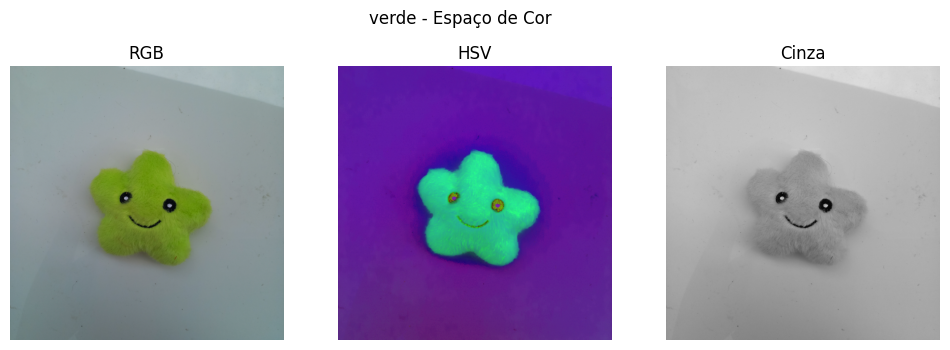

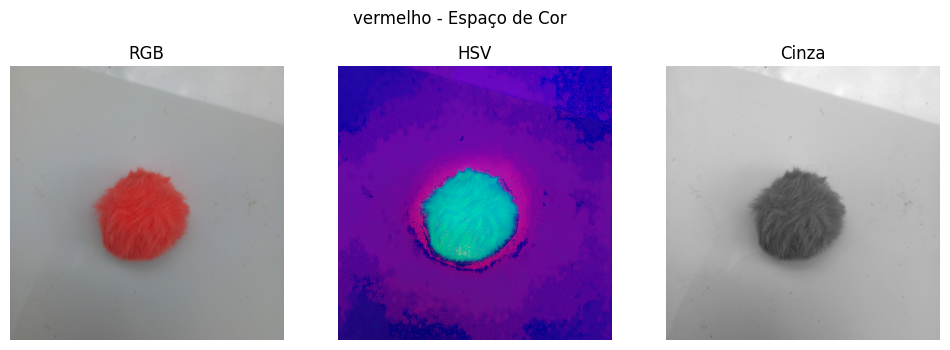

In [ ]:
def mostrar_cores(img, titulo):
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    fig, ax = plt.subplots(1, 3, figsize=(12,4))

    ax[0].imshow(img)
    ax[0].set_title("RGB")

    ax[1].imshow(hsv)
    ax[1].set_title("HSV")

    ax[2].imshow(gray, cmap="gray")
    ax[2].set_title("Cinza")

    for a in ax:
        a.axis("off")

    plt.suptitle(titulo)
    plt.show()

mostrar_cores(img_verde, "verde - Espaço de Cor")
mostrar_cores(img_vermelho, "vermelho - Espaço de Cor")

## 🔹 Espaço de Cor

Foram analisadas três representações da imagem:

- RGB
- HSV
- Escala de cinza

### 🎨 Diferenças visuais:

- **RGB:** Representação padrão com cores naturais.
- **HSV:** Separa informações de cor (Hue), saturação e brilho, facilitando a análise de cores específicas.
- **Escala de cinza:** Remove a informação de cor, mantendo apenas a intensidade luminosa.

### 🎯 Aplicações:

- **RGB:** Utilizado em tarefas gerais de classificação.
- **HSV:** Ideal para segmentação baseada em cor (ex: separar objeto do fundo).
- **Escala de cinza:** Reduz custo computacional e é útil em:
  - Detecção de bordas
  - Reconhecimento de formas

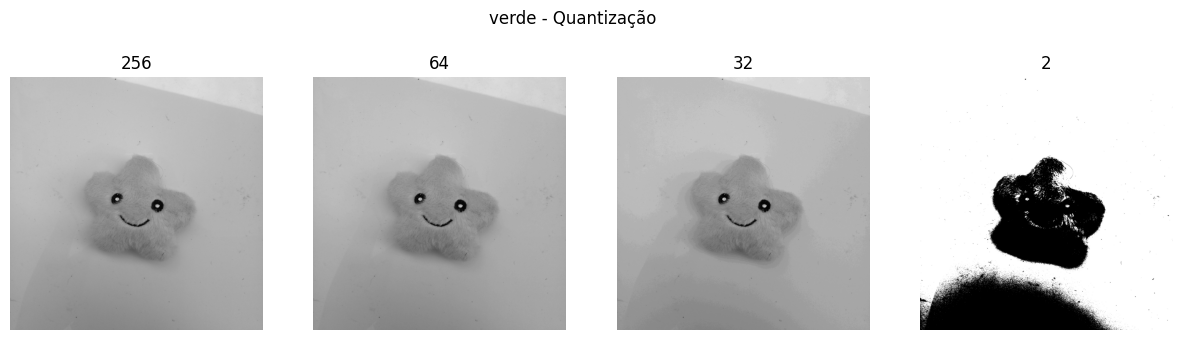

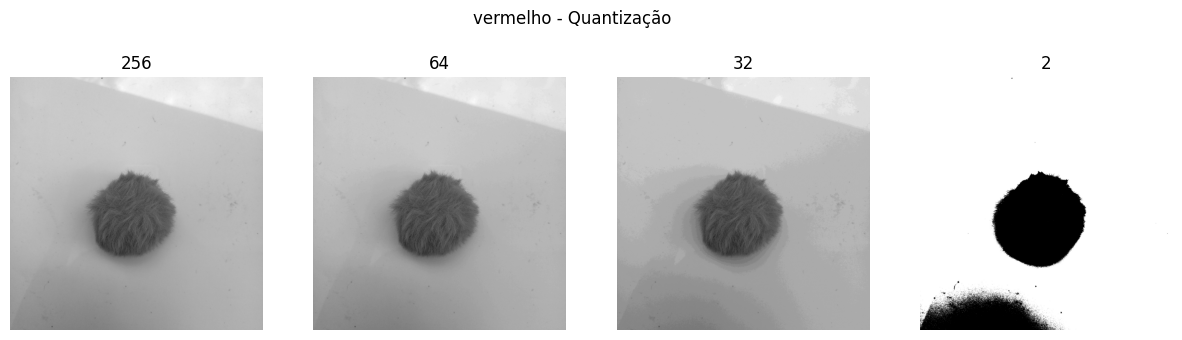

In [ ]:
import numpy as np

def quantizar(img, niveis):
    fator = 256 // niveis
    return (img // fator) * fator

def mostrar_quantizacao(img, titulo):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    q256 = quantizar(gray, 256)
    q64 = quantizar(gray, 64)
    q32 = quantizar(gray, 32)
    q2 = quantizar(gray, 2)

    fig, ax = plt.subplots(1, 4, figsize=(15,4))

    ax[0].imshow(q256, cmap="gray")
    ax[0].set_title("256")

    ax[1].imshow(q64, cmap="gray")
    ax[1].set_title("64")

    ax[2].imshow(q32, cmap="gray")
    ax[2].set_title("32")

    ax[3].imshow(q2, cmap="gray")
    ax[3].set_title("2")

    for a in ax:
        a.axis("off")

    plt.suptitle(titulo)
    plt.show()

mostrar_quantizacao(img_verde, "verde - Quantização")
mostrar_quantizacao(img_vermelho, "vermelho - Quantização")

## 🔹 Quantização

Foram geradas versões da imagem com diferentes níveis de cinza:

- 256 níveis
- 64 níveis
- 32 níveis
- 2 níveis

### 👁️ Observações visuais:

- **256 níveis:** Imagem original, com todos os detalhes preservados.
- **64 níveis:** Pequena perda de suavidade.
- **32 níveis:** Perda mais perceptível, com surgimento de "banding".
- **2 níveis:** Imagem binária (preto e branco), destacando apenas a estrutura geral.

### 🎯 Melhor uso:

- **32 e 64 níveis:** Melhor equilíbrio entre qualidade e custo computacional.
- **2 níveis:** Útil para:
  - Segmentação simples
  - Extração de silhuetas

### 📊 Aplicação no dataset:

A quantização pode ser utilizada para reduzir a complexidade dos dados, mantendo informações relevantes para classificação.

# FORMATO DE ARQUIVO

Tamanho JPEG: 203.57 KB
Tamanho PNG: 7561.91 KB


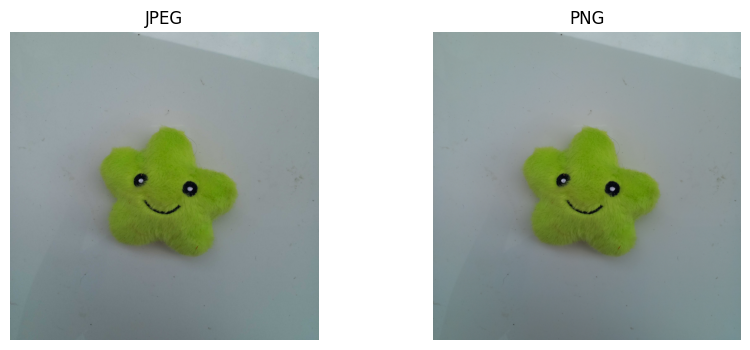

In [ ]:
import os

# salvar versões
cv2.imwrite("/content/teste.jpg", cv2.cvtColor(img_verde, cv2.COLOR_RGB2BGR), [int(cv2.IMWRITE_JPEG_QUALITY), 50])
cv2.imwrite("/content/teste.png", cv2.cvtColor(img_verde, cv2.COLOR_RGB2BGR))

# tamanho dos arquivos
tam_jpg = os.path.getsize("/content/teste.jpg") / 1024
tam_png = os.path.getsize("/content/teste.png") / 1024

print(f"Tamanho JPEG: {tam_jpg:.2f} KB")
print(f"Tamanho PNG: {tam_png:.2f} KB")

# mostrar imagens
img_jpg = cv2.cvtColor(cv2.imread("/content/teste.jpg"), cv2.COLOR_BGR2RGB)
img_png = cv2.cvtColor(cv2.imread("/content/teste.png"), cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].imshow(img_jpg)
ax[0].set_title("JPEG")

ax[1].imshow(img_png)
ax[1].set_title("PNG")

for a in ax:
    a.axis("off")

plt.show()

## 🔹 Formato de Arquivo

As imagens foram salvas em dois formatos:

- JPEG (com compressão)
- PNG (sem perdas)

### 📦 Tamanho dos arquivos:

- JPEG apresenta menor tamanho devido à compressão com perdas.
- PNG possui maior tamanho por preservar todos os detalhes da imagem.

### 👁️ Diferença visual:

- JPEG pode apresentar artefatos de compressão, especialmente em bordas.
- PNG mantém a qualidade original da imagem.

### 🧠 Impacto em Processamento de Imagens (PDI):

- **JPEG:** Mais eficiente para armazenamento e uso em grandes datasets.
- **PNG:** Mais indicado quando é necessária alta precisão, como em:
  - Detecção de defeitos
  - Análise detalhada de imagem